# Bangalore Ride Analytics: Demand, Cancellations & Trip Insights

## 01 — Data Understanding, Quality & Preparation

### Business Objective
Analyze Bangalore ride data to understand ride completion, cancellation, revenue, service, route and time-based performance.




In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path("..")

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "rides_data.csv"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned_rides.csv"
REPORTS_PATH = PROJECT_ROOT / "reports"

print("Raw data path:", RAW_DATA_PATH)
print("Processed data path:", PROCESSED_DATA_PATH)


Raw data path: ..\data\raw\rides_data.csv
Processed data path: ..\data\processed\cleaned_rides.csv


In [3]:
# ============================================================
# CHECK INPUT FILE
# ============================================================

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {RAW_DATA_PATH}"
    )

print("Dataset found successfully.")


Dataset found successfully.


In [4]:
# ============================================================
# LOAD RAW DATASET
# ============================================================

df = pd.read_csv(RAW_DATA_PATH)

print("Dataset loaded successfully.")


Dataset loaded successfully.


In [5]:
# ============================================================
# BASIC DATASET OVERVIEW
# ============================================================

print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]:,}")

display(df.head())
display(df.tail())


Number of rows    : 50,000
Number of columns : 13


,services,date,time,ride_status,source,destination,duration,ride_id,distance,ride_charge,misc_charge,total_fare,payment_method
0,cab economy,2024-07-15,08:30:40.542646,completed,Balagere Harbor,Harohalli Nagar,39,RD3161218751875354,27.21,764.83,31.51,796.34,Amazon Pay
1,auto,2024-07-05,23:36:51.542646,completed,Basavanagudi 3rd Block,Bikasipura 1st Stage,89,RD8171514284594096,34.03,314.83,49.52,364.35,Paytm
2,auto,2024-07-23,11:05:37.542646,cancelled,Babusapalya Cove,Kothaguda Terrace,25,RD9376481122237926,20.24,NaN,NaN,NaN,NaN
3,cab economy,2024-06-24,08:45:10.542646,completed,Mahadevapura Mews,Kanakapura Arc,89,RD3676889143182765,31.17,484.73,15.84,500.57,QR scan
4,cab economy,2024-07-15,00:26:44.542646,completed,Ganganagar Cove,Basaveshwaranagar Colony,95,RD6639410275948084,27.21,663.50,14.13,677.63,Amazon Pay


,services,date,time,ride_status,source,destination,duration,ride_id,distance,ride_charge,misc_charge,total_fare,payment_method
49995,cab economy,2024-07-24,10:12:37.811393,completed,Giri Nagar Quarters,Lingarajapuram Village,79,RD1742789687725650,7.03,518.90,23.81,542.71,Amazon Pay
49996,auto,2024-08-12,11:24:08.811393,completed,Hennur Road District,Hulimavu Pier,39,RD3524793949448023,31.77,977.34,2.67,980.01,Paytm
49997,bike,2024-08-10,21:52:48.811393,completed,Agara Heights,Ulsoor 4th Block,40,RD6755775741450371,25.74,331.94,38.32,370.26,Paytm
49998,auto,2024-07-07,20:44:00.811393,completed,Hosur Colony,Kanakapura Works,111,RD9198658614373790,11.70,565.47,0.33,565.80,Amazon Pay
49999,cab economy,2024-08-07,08:53:25.811393,completed,BTM 2nd Stage Depot,Thanisandra Pass,28,RD3094937631331884,43.52,673.43,44.17,717.60,Amazon Pay


In [6]:
# ============================================================
# COLUMN NAMES
# ============================================================

print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")


Columns in the dataset:

01. services
02. date
03. time
04. ride_status
05. source
06. destination
07. duration
08. ride_id
09. distance
10. ride_charge
11. misc_charge
12. total_fare
13. payment_method


In [7]:
# ============================================================
# DATA TYPES
# ============================================================

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   services        50000 non-null  str    
 1   date            50000 non-null  str    
 2   time            50000 non-null  str    
 3   ride_status     50000 non-null  str    
 4   source          50000 non-null  str    
 5   destination     50000 non-null  str    
 6   duration        50000 non-null  int64  
 7   ride_id         50000 non-null  str    
 8   distance        50000 non-null  float64
 9   ride_charge     44964 non-null  float64
 10  misc_charge     44964 non-null  float64
 11  total_fare      44964 non-null  float64
 12  payment_method  44964 non-null  str    
dtypes: float64(4), int64(1), str(8)
memory usage: 5.0 MB


In [8]:
# ============================================================
# STATISTICAL SUMMARY
# ============================================================

display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
services,50000,5,bike,15128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,50000,61,2024-08-03,888,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,50000,49363,19:55:36.542646,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ride_status,50000,2,completed,44964,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,50000,12982,Kothanur Landing,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination,50000,12977,Gottigere Landing,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,50000.0,NaN,NaN,NaN,64.3201,31.852336,10.0,37.0,64.0,92.0,119.0
ride_id,50000,50000,RD3161218751875354,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distance,50000.0,NaN,NaN,NaN,25.528243,14.177136,1.0,13.26,25.46,37.86,50.0
ride_charge,44964.0,NaN,NaN,NaN,522.428805,274.726031,50.03,283.6575,520.03,759.3675,999.96


In [9]:
# ============================================================
# MISSING VALUE ANALYSIS
# ============================================================

missing_summary = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percentage": (df.isna().mean().values * 100).round(2)
}).sort_values("missing_percentage", ascending=False)

display(missing_summary)
display(missing_summary[missing_summary["missing_count"] > 0])


,column,missing_count,missing_percentage
12,payment_method,5036,10.07
9,ride_charge,5036,10.07
10,misc_charge,5036,10.07
11,total_fare,5036,10.07
0,services,0,0.00
4,source,0,0.00
3,ride_status,0,0.00
2,time,0,0.00
1,date,0,0.00
8,distance,0,0.00


,column,missing_count,missing_percentage
12,payment_method,5036,10.07
9,ride_charge,5036,10.07
10,misc_charge,5036,10.07
11,total_fare,5036,10.07


In [10]:
# ============================================================
# DUPLICATE ANALYSIS
# ============================================================

duplicate_rows = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows:,}")
print(f"Duplicate percentage: {duplicate_rows / len(df) * 100:.2f}%")


Duplicate rows: 0
Duplicate percentage: 0.00%


In [11]:
# ============================================================
# RIDE ID QUALITY CHECK
# ============================================================

if "ride_id" in df.columns:
    duplicate_ride_ids = df["ride_id"].duplicated().sum()
    unique_ride_ids = df["ride_id"].nunique()

    print(f"Total records      : {len(df):,}")
    print(f"Unique ride IDs    : {unique_ride_ids:,}")
    print(f"Duplicate ride IDs : {duplicate_ride_ids:,}")


Total records      : 50,000
Unique ride IDs    : 50,000
Duplicate ride IDs : 0


In [12]:
# ============================================================
# CATEGORICAL VALUE INSPECTION
# ============================================================

categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:

    print("\n" + "=" * 70)
    print(f"COLUMN: {column}")
    print("=" * 70)

    print(
        df[column]
        .value_counts(dropna=False)
        .head(20)
    )


COLUMN: services
services
bike           15128
auto           12327
cab economy    10202
parcel          7459
bike lite       4884
Name: count, dtype: int64

COLUMN: date
date
2024-08-03    888
2024-07-29    871
2024-07-14    871
2024-08-10    860
2024-06-24    856
2024-06-27    852
2024-07-31    849
2024-08-05    845
2024-07-18    844
2024-07-15    842
2024-07-08    842
2024-07-09    842
2024-06-21    841
2024-07-06    841
2024-07-16    840
2024-08-08    839
2024-07-17    837
2024-07-05    832
2024-06-26    832
2024-08-04    831
Name: count, dtype: int64

COLUMN: time


C:\Users\adity\AppData\Local\Temp\ipykernel_12700\3872852773.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


time
19:55:36.542646    3
00:52:10.689686    3
19:53:59.689686    3
02:11:36.689686    3
10:54:01.735376    3
03:38:25.754771    3
17:02:52.754771    3
08:26:32.771041    3
22:37:33.542646    2
01:04:02.542646    2
03:02:03.542646    2
10:47:12.542646    2
19:34:09.542646    2
23:56:12.542646    2
20:54:55.542646    2
05:31:57.542646    2
01:31:26.542646    2
03:05:21.542646    2
10:40:42.542646    2
14:48:08.542646    2
Name: count, dtype: int64

COLUMN: ride_status
ride_status
completed    44964
cancelled     5036
Name: count, dtype: int64

COLUMN: source
source
Kothanur Landing            23
Vijayanagar Square          20
Banaswadi Landing           20
HRBR Layout Landing         19
Ramamurthy Nagar Landing    18
Banaswadi Square            17
HRBR Layout Square          16
Kalyan Nagar Landing        15
Chokkanahalli Landing       15
Kothanur 6th Block          15
Kalyan Nagar Close          15
HRBR Layout Bay             14
HRBR Layout Cutting         14
Kothanur Colony           

In [13]:
# ============================================================
# NUMERICAL COLUMN INSPECTION
# ============================================================

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
for column in numeric_columns:
    print(f"- {column}")

display(df[numeric_columns].describe().T)


Numerical columns:
- duration
- distance
- ride_charge
- misc_charge
- total_fare


,count,mean,std,min,25%,50%,75%,max
duration,50000.0,64.320100,31.852336,10.00,37.0000,64.00,92.0000,119.00
distance,50000.0,25.528243,14.177136,1.00,13.2600,25.46,37.8600,50.00
ride_charge,44964.0,522.428805,274.726031,50.03,283.6575,520.03,759.3675,999.96
misc_charge,44964.0,24.964289,14.459417,0.00,12.4000,25.07,37.5100,50.00
total_fare,44964.0,547.393093,275.094813,50.58,308.9200,544.92,785.5025,1048.80


In [14]:
# ============================================================
# NUMERICAL VALIDATION
# ============================================================

columns_to_check = [
    "duration",
    "distance",
    "ride_charge",
    "misc_charge",
    "total_fare"
]

for column in columns_to_check:
    if column in df.columns:
        negative_count = (df[column] < 0).sum()
        print(f"{column:<20} negative values: {negative_count:,}")


duration             negative values: 0
distance             negative values: 0
ride_charge          negative values: 0
misc_charge          negative values: 0
total_fare           negative values: 0


In [15]:
# ============================================================
# RIDE STATUS ANALYSIS
# ============================================================

if "ride_status" in df.columns:
    status_summary = (
        df["ride_status"]
        .value_counts(dropna=False)
        .reset_index()
    )
    status_summary.columns = ["ride_status", "ride_count"]
    display(status_summary)

    print("Unique ride statuses:")
    print(df["ride_status"].unique())


,ride_status,ride_count
0,completed,44964
1,cancelled,5036


Unique ride statuses:
<StringArray>
['completed', 'cancelled']
Length: 2, dtype: str


In [16]:
# ============================================================
# SERVICE TYPE ANALYSIS
# ============================================================

if "services" in df.columns:
    service_summary = (
        df["services"]
        .value_counts(dropna=False)
        .reset_index()
    )
    service_summary.columns = ["service_type", "ride_count"]
    display(service_summary)


,service_type,ride_count
0,bike,15128
1,auto,12327
2,cab economy,10202
3,parcel,7459
4,bike lite,4884


In [17]:
# ============================================================
# CREATE CLEANING DATAFRAME
# ============================================================

clean_df = df.copy()

print(f"Working dataset created with {len(clean_df):,} records.")


Working dataset created with 50,000 records.


In [18]:
# ============================================================
# STANDARDIZE COLUMN NAMES
# ============================================================

clean_df.columns = (
    clean_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(clean_df.columns.tolist())


['services', 'date', 'time', 'ride_status', 'source', 'destination', 'duration', 'ride_id', 'distance', 'ride_charge', 'misc_charge', 'total_fare', 'payment_method']


In [19]:
# ============================================================
# REMOVE EXACT DUPLICATES
# ============================================================

rows_before = len(clean_df)

clean_df = clean_df.drop_duplicates()

rows_after = len(clean_df)

print(f"Rows before removing duplicates : {rows_before:,}")
print(f"Rows after removing duplicates  : {rows_after:,}")
print(f"Rows removed                    : {rows_before - rows_after:,}")


Rows before removing duplicates : 50,000
Rows after removing duplicates  : 50,000
Rows removed                    : 0


In [20]:
# ============================================================
# DATE CONVERSION
# ============================================================

if "date" in clean_df.columns:
    clean_df["date"] = pd.to_datetime(
        clean_df["date"],
        errors="coerce"
    )
    print("Invalid dates:", clean_df["date"].isna().sum())


Invalid dates: 0


In [21]:
# ============================================================
# TIME CONVERSION
# ============================================================

if "time" in clean_df.columns:
    clean_df["time"] = pd.to_datetime(
        clean_df["time"],
        errors="coerce"
    ).dt.time
    print("Missing/invalid times:", clean_df["time"].isna().sum())


C:\Users\adity\AppData\Local\Temp\ipykernel_12700\3470878744.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  clean_df["time"] = pd.to_datetime(


Missing/invalid times: 0


In [22]:
# ============================================================
# CREATE BOOKING DATETIME
# ============================================================

clean_df["booking_datetime"] = pd.to_datetime(
    clean_df["date"].astype(str) + " " + clean_df["time"].astype(str),
    errors="coerce"
)

print(
    "Invalid booking datetime values:",
    clean_df["booking_datetime"].isna().sum()
)

display(clean_df[["date", "time", "booking_datetime"]].head())


Invalid booking datetime values: 0


,date,time,booking_datetime
0,2024-07-15,08:30:40.542646,2024-07-15 08:30:40.542646
1,2024-07-05,23:36:51.542646,2024-07-05 23:36:51.542646
2,2024-07-23,11:05:37.542646,2024-07-23 11:05:37.542646
3,2024-06-24,08:45:10.542646,2024-06-24 08:45:10.542646
4,2024-07-15,00:26:44.542646,2024-07-15 00:26:44.542646


In [23]:
# ============================================================
# NUMERICAL DATA TYPE STANDARDIZATION
# ============================================================

numeric_columns = [
    "duration",
    "distance",
    "ride_charge",
    "misc_charge",
    "total_fare"
]

for column in numeric_columns:
    if column in clean_df.columns:
        clean_df[column] = pd.to_numeric(
            clean_df[column],
            errors="coerce"
        )

print("Numerical columns standardized.")


Numerical columns standardized.


In [24]:
# ============================================================
# CLEAN SERVICE TYPE
# ============================================================

clean_df["service_type_clean"] = (
    clean_df["services"]
    .astype("string")
    .str.strip()
    .str.lower()
)

display(clean_df["service_type_clean"].value_counts(dropna=False))


service_type_clean
bike           15128
auto           12327
cab economy    10202
parcel          7459
bike lite       4884
Name: count, dtype: Int64

In [25]:
# ============================================================
# CLEAN LOCATION FIELDS
# ============================================================

clean_df["source_clean"] = (
    clean_df["source"]
    .astype("string")
    .str.strip()
    .str.lower()
)

clean_df["destination_clean"] = (
    clean_df["destination"]
    .astype("string")
    .str.strip()
    .str.lower()
)


In [26]:
# ============================================================
# CLEAN PAYMENT METHOD
# ============================================================

clean_df["payment_method_clean"] = (
    clean_df["payment_method"]
    .astype("string")
    .str.strip()
    .str.lower()
)

display(clean_df["payment_method_clean"].value_counts(dropna=False))


payment_method_clean
paytm         11315
gpay          11268
amazon pay    11225
qr scan       11156
<NA>           5036
Name: count, dtype: Int64

In [27]:
# ============================================================
# RIDE OUTCOME FLAGS
# ============================================================
# IMPORTANT:
# Confirm the actual status labels in the previous cell.
# This mapping assumes the dataset uses "Completed" and "Cancelled".

clean_df["is_completed"] = (
    clean_df["ride_status"]
    .astype("string")
    .str.strip()
    .str.lower()
    .eq("completed")
    .astype(int)
)

clean_df["is_cancelled"] = (
    clean_df["ride_status"]
    .astype("string")
    .str.strip()
    .str.lower()
    .eq("cancelled")
    .astype(int)
)

outcome_check = (
    clean_df[
        ["ride_status", "is_completed", "is_cancelled"]
    ]
    .drop_duplicates()
    .sort_values("ride_status")
)

display(outcome_check)


,ride_status,is_completed,is_cancelled
2,cancelled,0,1
0,completed,1,0


In [28]:
# ============================================================
# TIME-BASED FEATURES
# ============================================================

clean_df["booking_date"] = clean_df["booking_datetime"].dt.date
clean_df["hour"] = clean_df["booking_datetime"].dt.hour
clean_df["day_of_week"] = clean_df["booking_datetime"].dt.day_name()
clean_df["day_of_week_num"] = clean_df["booking_datetime"].dt.dayofweek
clean_df["is_weekend"] = clean_df["day_of_week_num"] >= 5
clean_df["month"] = clean_df["booking_datetime"].dt.month
clean_df["month_name"] = clean_df["booking_datetime"].dt.month_name()
clean_df["week_of_year"] = clean_df["booking_datetime"].dt.isocalendar().week

print("Time features created.")


Time features created.


In [29]:
# ============================================================
# BUSINESS TIME PERIOD CLASSIFICATION
# ============================================================

def classify_time_period(hour):
    if 6 <= hour < 10:
        return "Morning Peak"
    elif 10 <= hour < 16:
        return "Daytime"
    elif 16 <= hour < 20:
        return "Evening Peak"
    elif 20 <= hour < 24:
        return "Night"
    else:
        return "Late Night"

clean_df["time_period"] = clean_df["hour"].apply(classify_time_period)

display(clean_df["time_period"].value_counts())


time_period
Daytime         12575
Late Night      12393
Morning Peak     8476
Evening Peak     8301
Night            8255
Name: count, dtype: int64

In [30]:
# ============================================================
# ROUTE FEATURE
# ============================================================

clean_df["route"] = (
    clean_df["source_clean"] + " → " + clean_df["destination_clean"]
)

display(clean_df["route"].head())


0                balagere harbor → harohalli nagar
1    basavanagudi 3rd block → bikasipura 1st stage
2             babusapalya cove → kothaguda terrace
3               mahadevapura mews → kanakapura arc
4       ganganagar cove → basaveshwaranagar colony
Name: route, dtype: string

In [31]:
# ============================================================
# DISTANCE BUCKETS
# ============================================================

clean_df["distance_bucket"] = pd.cut(
    clean_df["distance"],
    bins=[-np.inf, 3, 7, 15, np.inf],
    labels=[
        "Short (≤3 km)",
        "Medium (3–7 km)",
        "Long (7–15 km)",
        "Very Long (>15 km)"
    ]
)

display(clean_df["distance_bucket"].value_counts(dropna=False))


distance_bucket
Very Long (>15 km)    35747
Long (7–15 km)         8120
Medium (3–7 km)        4081
Short (≤3 km)          2052
Name: count, dtype: int64

In [32]:
# ============================================================
# DURATION BUCKETS
# ============================================================

clean_df["duration_bucket"] = pd.cut(
    clean_df["duration"],
    bins=[-np.inf, 15, 30, 60, np.inf],
    labels=[
        "Short (≤15 min)",
        "Medium (15–30 min)",
        "Long (30–60 min)",
        "Very Long (>60 min)"
    ]
)

display(clean_df["duration_bucket"].value_counts(dropna=False))


duration_bucket
Very Long (>60 min)    26665
Long (30–60 min)       13636
Medium (15–30 min)      6913
Short (≤15 min)         2786
Name: count, dtype: int64

In [33]:
# ============================================================
# FARE BUCKETS
# ============================================================

clean_df["fare_bucket"] = pd.qcut(
    clean_df["total_fare"],
    q=4,
    labels=[
        "Low Fare",
        "Medium-Low Fare",
        "Medium-High Fare",
        "High Fare"
    ],
    duplicates="drop"
)

display(clean_df["fare_bucket"].value_counts(dropna=False))


fare_bucket
Low Fare            11241
Medium-Low Fare     11241
Medium-High Fare    11241
High Fare           11241
NaN                  5036
Name: count, dtype: int64

In [34]:
# ============================================================
# FARE EFFICIENCY
# ============================================================

clean_df["fare_per_km"] = np.where(
    clean_df["distance"] > 0,
    clean_df["total_fare"] / clean_df["distance"],
    np.nan
)

display(clean_df["fare_per_km"].describe())


count    44964.000000
mean        43.759829
std         74.613382
min          1.190376
25%         12.001117
50%         21.544433
75%         41.510471
max        995.800000
Name: fare_per_km, dtype: float64

In [35]:
# ============================================================
# FINAL DATA QUALITY CHECK
# ============================================================

final_quality = pd.DataFrame({
    "column": clean_df.columns,
    "data_type": clean_df.dtypes.astype(str).values,
    "missing_count": clean_df.isna().sum().values,
    "missing_percentage": (clean_df.isna().mean() * 100).round(2).values,
    "unique_values": clean_df.nunique().values
}).sort_values("missing_percentage", ascending=False)

display(final_quality.head(20))


,column,data_type,missing_count,missing_percentage,unique_values
12,payment_method,str,5036,10.07,4
9,ride_charge,float64,5036,10.07,35870
17,payment_method_clean,string,5036,10.07,4
33,fare_per_km,float64,5036,10.07,44956
11,total_fare,float64,5036,10.07,37414
10,misc_charge,float64,5036,10.07,5001
32,fare_bucket,category,5036,10.07,4
0,services,str,0,0.00,5
1,date,datetime64[us],0,0.00,61
2,time,object,0,0.00,49363


In [36]:
# ============================================================
# FINAL VALIDATION
# ============================================================

print("=" * 60)
print("FINAL DATASET VALIDATION")
print("=" * 60)

print(f"Rows    : {clean_df.shape[0]:,}")
print(f"Columns : {clean_df.shape[1]:,}")
print(f"Duplicate rows: {clean_df.duplicated().sum():,}")
print(f"Duplicate ride IDs: {clean_df['ride_id'].duplicated().sum():,}")
print(f"Missing booking datetime: {clean_df['booking_datetime'].isna().sum():,}")
print(f"Negative distance: {(clean_df['distance'] < 0).sum():,}")
print(f"Negative duration: {(clean_df['duration'] < 0).sum():,}")
print(f"Negative fare: {(clean_df['total_fare'] < 0).sum():,}")


FINAL DATASET VALIDATION
Rows    : 50,000
Columns : 34
Duplicate rows: 0
Duplicate ride IDs: 0
Missing booking datetime: 0
Negative distance: 0
Negative duration: 0
Negative fare: 0


In [37]:
# ============================================================
# FINAL COLUMN LIST
# ============================================================

for i, column in enumerate(clean_df.columns, start=1):
    print(f"{i:02d}. {column}")


01. services
02. date
03. time
04. ride_status
05. source
06. destination
07. duration
08. ride_id
09. distance
10. ride_charge
11. misc_charge
12. total_fare
13. payment_method
14. booking_datetime
15. service_type_clean
16. source_clean
17. destination_clean
18. payment_method_clean
19. is_completed
20. is_cancelled
21. booking_date
22. hour
23. day_of_week
24. day_of_week_num
25. is_weekend
26. month
27. month_name
28. week_of_year
29. time_period
30. route
31. distance_bucket
32. duration_bucket
33. fare_bucket
34. fare_per_km


In [38]:
# ============================================================
# SAVE PROCESSED DATASET
# ============================================================

PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

clean_df.to_csv(
    PROCESSED_DATA_PATH,
    index=False
)

print(f"Cleaned dataset saved successfully:\n{PROCESSED_DATA_PATH}")


Cleaned dataset saved successfully:
..\data\processed\cleaned_rides.csv


In [39]:
# ============================================================
# PROCESSED FILE VALIDATION
# ============================================================

validation_df = pd.read_csv(PROCESSED_DATA_PATH)

print(
    f"Saved file contains "
    f"{validation_df.shape[0]:,} rows and "
    f"{validation_df.shape[1]:,} columns."
)

display(validation_df.head())


Saved file contains 50,000 rows and 34 columns.


,services,date,time,ride_status,source,destination,duration,ride_id,distance,ride_charge,misc_charge,total_fare,payment_method,booking_datetime,service_type_clean,source_clean,destination_clean,payment_method_clean,is_completed,is_cancelled,booking_date,hour,day_of_week,day_of_week_num,is_weekend,month,month_name,week_of_year,time_period,route,distance_bucket,duration_bucket,fare_bucket,fare_per_km
0,cab economy,2024-07-15,08:30:40.542646,completed,Balagere Harbor,Harohalli Nagar,39,RD3161218751875354,27.21,764.83,31.51,796.34,Amazon Pay,2024-07-15 08:30:40.542646,cab economy,balagere harbor,harohalli nagar,amazon pay,1,0,2024-07-15,8,Monday,0,False,7,July,29,Morning Peak,balagere harbor → harohalli nagar,Very Long (>15 km),Long (30–60 min),High Fare,29.266446
1,auto,2024-07-05,23:36:51.542646,completed,Basavanagudi 3rd Block,Bikasipura 1st Stage,89,RD8171514284594096,34.03,314.83,49.52,364.35,Paytm,2024-07-05 23:36:51.542646,auto,basavanagudi 3rd block,bikasipura 1st stage,paytm,1,0,2024-07-05,23,Friday,4,False,7,July,27,Night,basavanagudi 3rd block → bikasipura 1st stage,Very Long (>15 km),Very Long (>60 min),Medium-Low Fare,10.706729
2,auto,2024-07-23,11:05:37.542646,cancelled,Babusapalya Cove,Kothaguda Terrace,25,RD9376481122237926,20.24,NaN,NaN,NaN,NaN,2024-07-23 11:05:37.542646,auto,babusapalya cove,kothaguda terrace,NaN,0,1,2024-07-23,11,Tuesday,1,False,7,July,30,Daytime,babusapalya cove → kothaguda terrace,Very Long (>15 km),Medium (15–30 min),NaN,NaN
3,cab economy,2024-06-24,08:45:10.542646,completed,Mahadevapura Mews,Kanakapura Arc,89,RD3676889143182765,31.17,484.73,15.84,500.57,QR scan,2024-06-24 08:45:10.542646,cab economy,mahadevapura mews,kanakapura arc,qr scan,1,0,2024-06-24,8,Monday,0,False,6,June,26,Morning Peak,mahadevapura mews → kanakapura arc,Very Long (>15 km),Very Long (>60 min),Medium-Low Fare,16.059352
4,cab economy,2024-07-15,00:26:44.542646,completed,Ganganagar Cove,Basaveshwaranagar Colony,95,RD6639410275948084,27.21,663.50,14.13,677.63,Amazon Pay,2024-07-15 00:26:44.542646,cab economy,ganganagar cove,basaveshwaranagar colony,amazon pay,1,0,2024-07-15,0,Monday,0,False,7,July,29,Late Night,ganganagar cove → basaveshwaranagar colony,Very Long (>15 km),Very Long (>60 min),Medium-High Fare,24.903712


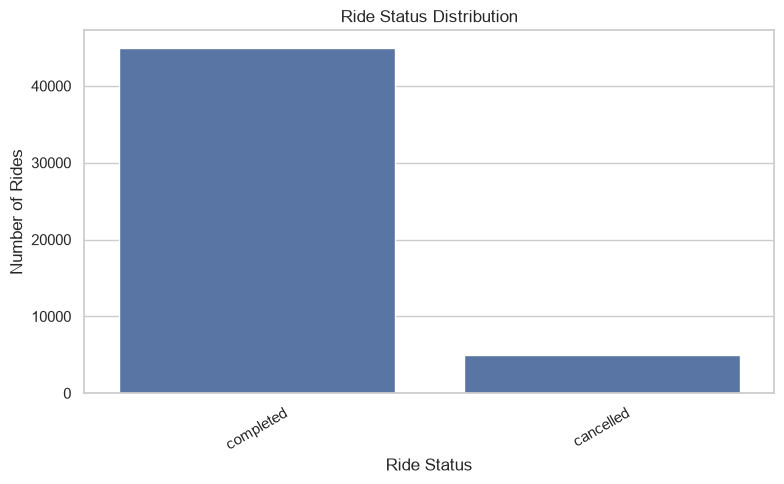

In [40]:
# ============================================================
# RIDE STATUS DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_df,
    x="ride_status"
)

plt.title("Ride Status Distribution")
plt.xlabel("Ride Status")
plt.ylabel("Number of Rides")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


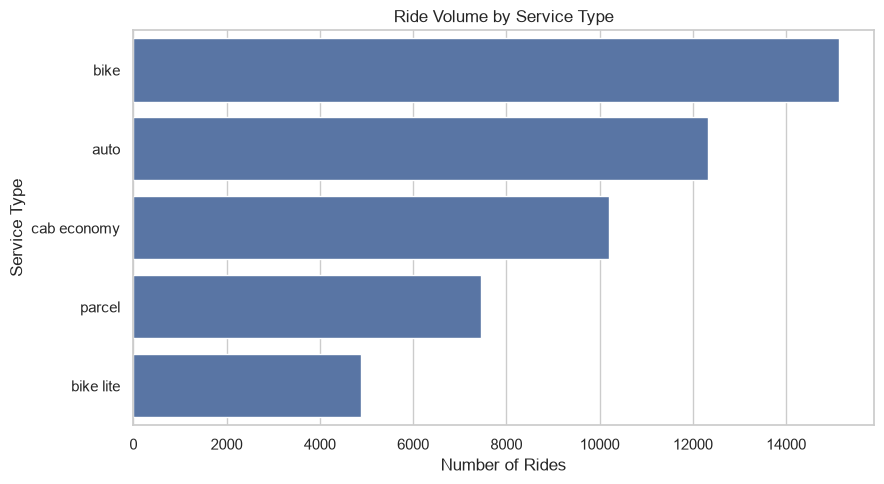

In [41]:
# ============================================================
# SERVICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

service_counts = clean_df["service_type_clean"].value_counts()

sns.barplot(
    x=service_counts.values,
    y=service_counts.index
)

plt.title("Ride Volume by Service Type")
plt.xlabel("Number of Rides")
plt.ylabel("Service Type")

plt.tight_layout()
plt.show()


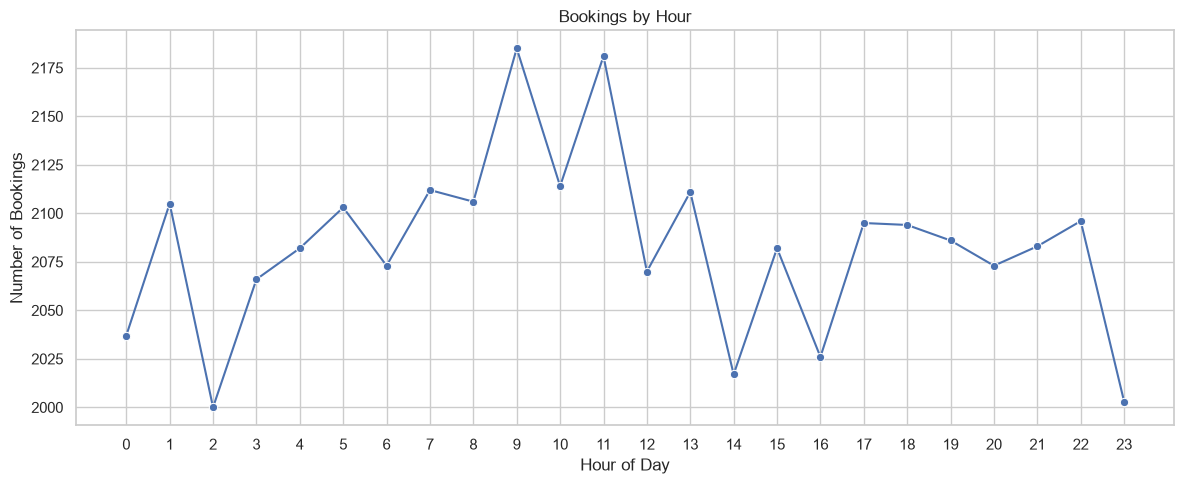

In [42]:
# ============================================================
# HOURLY BOOKING PATTERN
# ============================================================

hourly_bookings = (
    clean_df
    .groupby("hour")
    .size()
    .reset_index(name="bookings")
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly_bookings,
    x="hour",
    y="bookings",
    marker="o"
)

plt.title("Bookings by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Bookings")

plt.xticks(range(24))
plt.tight_layout()
plt.show()


In [43]:
# ============================================================
# EXPORT DATA QUALITY REPORT
# ============================================================

REPORTS_PATH.mkdir(parents=True, exist_ok=True)

final_quality.to_excel(
    REPORTS_PATH / "data_quality_summary.xlsx",
    index=False
)

print("Data quality report exported.")


Data quality report exported.


In [44]:
df.columns


Index(['services', 'date', 'time', 'ride_status', 'source', 'destination', 'duration', 'ride_id', 'distance',
       'ride_charge', 'misc_charge', 'total_fare', 'payment_method'],
      dtype='str')

In [45]:
!pip install psycopg2-binary

In [ ]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

# ============================================================
# CONNECT TO POSTGRESQL
# ============================================================

username = "postgres"
password = "Your_db_passowrd"          # Replace with your PostgreSQL password
host = "localhost"
port = "5432"
database = "database_name"

encoded_password = quote_plus(password)

engine = create_engine(
    f"postgresql+psycopg2://{username}:{encoded_password}"
    f"@{host}:{port}/{database}"
)

# ============================================================
# LOAD CLEANED DATAFRAME INTO POSTGRESQL
# ============================================================

table_name = "rides"

clean_df.to_sql(
    table_name,
    engine,
    if_exists="replace",
    index=False
)

print(
    f"Data successfully loaded into table "
    f"'{table_name}' in database '{database}'."
)

Data successfully loaded into table 'rides' in database 'bangalore_mobility'.
